# Preprocessing of Neighbourhoods File

In [8]:
import pandas as pd
import numpy as np
import prep_functions as prep
from datetime import datetime

## 1. Reading in both given listings_files

In [9]:
listings = pd.read_csv('../Data/listings.csv')
listings.info()
listings.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7921 entries, 0 to 7920
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7921 non-null   int64  
 1   listing_url                                   7921 non-null   object 
 2   scrape_id                                     7921 non-null   int64  
 3   last_scraped                                  7921 non-null   object 
 4   source                                        7921 non-null   object 
 5   name                                          7921 non-null   object 
 6   description                                   7705 non-null   object 
 7   neighborhood_overview                         4489 non-null   object 
 8   picture_url                                   7920 non-null   object 
 9   host_id                                       7921 non-null   i

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6624,https://www.airbnb.com/rooms/6624,20250302033917,2025-03-02,city scrape,Venice garden charme and canal view!,I'm thrilled to share my apartment with garden...,We are in the middle of a residential area cal...,https://a0.muscache.com/pictures/65440024/a564...,15016,...,4.88,4.95,4.92,"I applied for a CIN, but haven’t received it yet",f,1,1,0,0,0.54
1,27116,https://www.airbnb.com/rooms/27116,20250302033917,2025-03-02,city scrape,Junior Suite with balcony overlooking canal,"Few steps from Saint Mark square, on a picture...","The area is very beautiful and characteristic,...",https://a0.muscache.com/pictures/miso/Hosting-...,116144,...,4.81,4.94,4.78,IT027042B4RZ8EK8UI,t,3,1,2,0,2.33
2,44527,https://www.airbnb.com/rooms/44527,20250302033917,2025-03-02,city scrape,Luxury Historic Apartment on Calm Sunny Canal,An apartment that blends Gothic style with ini...,"Cannaregio is a well-connected, truly Venetian...",https://a0.muscache.com/pictures/d81fb136-a867...,120215,...,4.94,4.91,4.71,IT027042B4GR0PSZS4,f,2,2,0,0,0.88
3,47383,https://www.airbnb.com/rooms/47383,20250302033917,2025-03-02,city scrape,Ca' Barba B&B: room n102 (jacuzzi shower),"Ca' Barb B&B, a few steps away from Rialto bri...",San Polo is highly rated by guests for walking...,https://a0.muscache.com/pictures/550179/3b2f0d...,214390,...,4.98,4.94,4.88,IT027042B4D3D4AUUS,t,4,1,0,0,2.32
4,49656,https://www.airbnb.com/rooms/49656,20250302033917,2025-03-02,city scrape,Ca' Foscari Apartment,It’s a lovely quiet newly restored flat within...,The apartment is on the first floor (second fl...,https://a0.muscache.com/pictures/41037529-8487...,226598,...,4.97,4.97,4.78,IT027042C2L6NZYNJR,t,2,2,0,0,0.87


## 2. Preprocess price column

In [10]:
def clean_price(df):
    df = df.dropna(subset=['price'])            # delete all rows with missing price
    df['price'] = df['price'].str.replace(',','').str[1:].astype(float)     # convert values to nicer format
    return df

listings = clean_price(listings)
# listings['price'].head(3)

C:\Users\bendi\AppData\Local\Temp\ipykernel_980\2906769099.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].str.replace(',','').str[1:].astype(float)     # convert values to nicer format


## 4. Deleting unused Columns

Ether because we generaly wont use them in our program or because they contain to many not sufficiant imputable values.

See column documentation under: 
https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596

In [11]:
delet_columns = [
    'calendar_updated', 'calendar_last_scraped', 'first_review', 'host_about', 
    'host_neighbourhood', 'host_picture_url', 'host_thumbnail_url',
    'license', 'neighborhood_overview', 'neighbourhood', 'source', 'host_verifications', 'amenities',
    'estimated_revenue_l365d', 'host_url', 'scrape_id', 'host_name']

listings = listings.drop(delet_columns, axis=1)

## 5. Convert Dtypes

In [12]:
listings['host_since']

0       2009-04-27
1       2010-04-30
2       2010-05-07
3       2010-08-27
4       2010-09-07
           ...    
7916    2024-12-20
7917    2012-06-14
7918    2018-02-13
7919    2024-12-20
7920    2024-12-20
Name: host_since, Length: 7017, dtype: object

In [13]:
# Register difference in days between last review date and the date of the last scrape
listings['host_since'] = pd.to_datetime(listings['host_since'])
listings['last_review'] = pd.to_datetime(listings['last_review'])
listings['last_scraped'] = pd.to_datetime(listings['last_scraped'])

listings['last_review_diff'] = (listings['last_scraped'].min() - listings['last_review']).dt.days
listings.drop(columns=['last_review'], inplace=True)

listings['host_since_diff'] = (listings['last_scraped'].min() - listings['host_since']).dt.days
listings.drop(columns=['host_since'], inplace=True)


# Convert percentage cols
percent_cols = ['host_response_rate', 'host_acceptance_rate']

for col in percent_cols:
    listings[col] = listings[col].str.strip('%')
    listings[col] = pd.to_numeric(listings[col], errors='coerce') / 100
    
listings[percent_cols].head()

,host_response_rate,host_acceptance_rate
0,1.0,0.74
1,1.0,1.00
2,1.0,1.00
3,1.0,1.00
4,1.0,1.00


## 5. Data Visualization

44


C:\Users\bendi\AppData\Local\Temp\ipykernel_980\2814234051.py:14: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  plt.scatter(y.ravel(), df[feature], s=2, alpha=0.5)


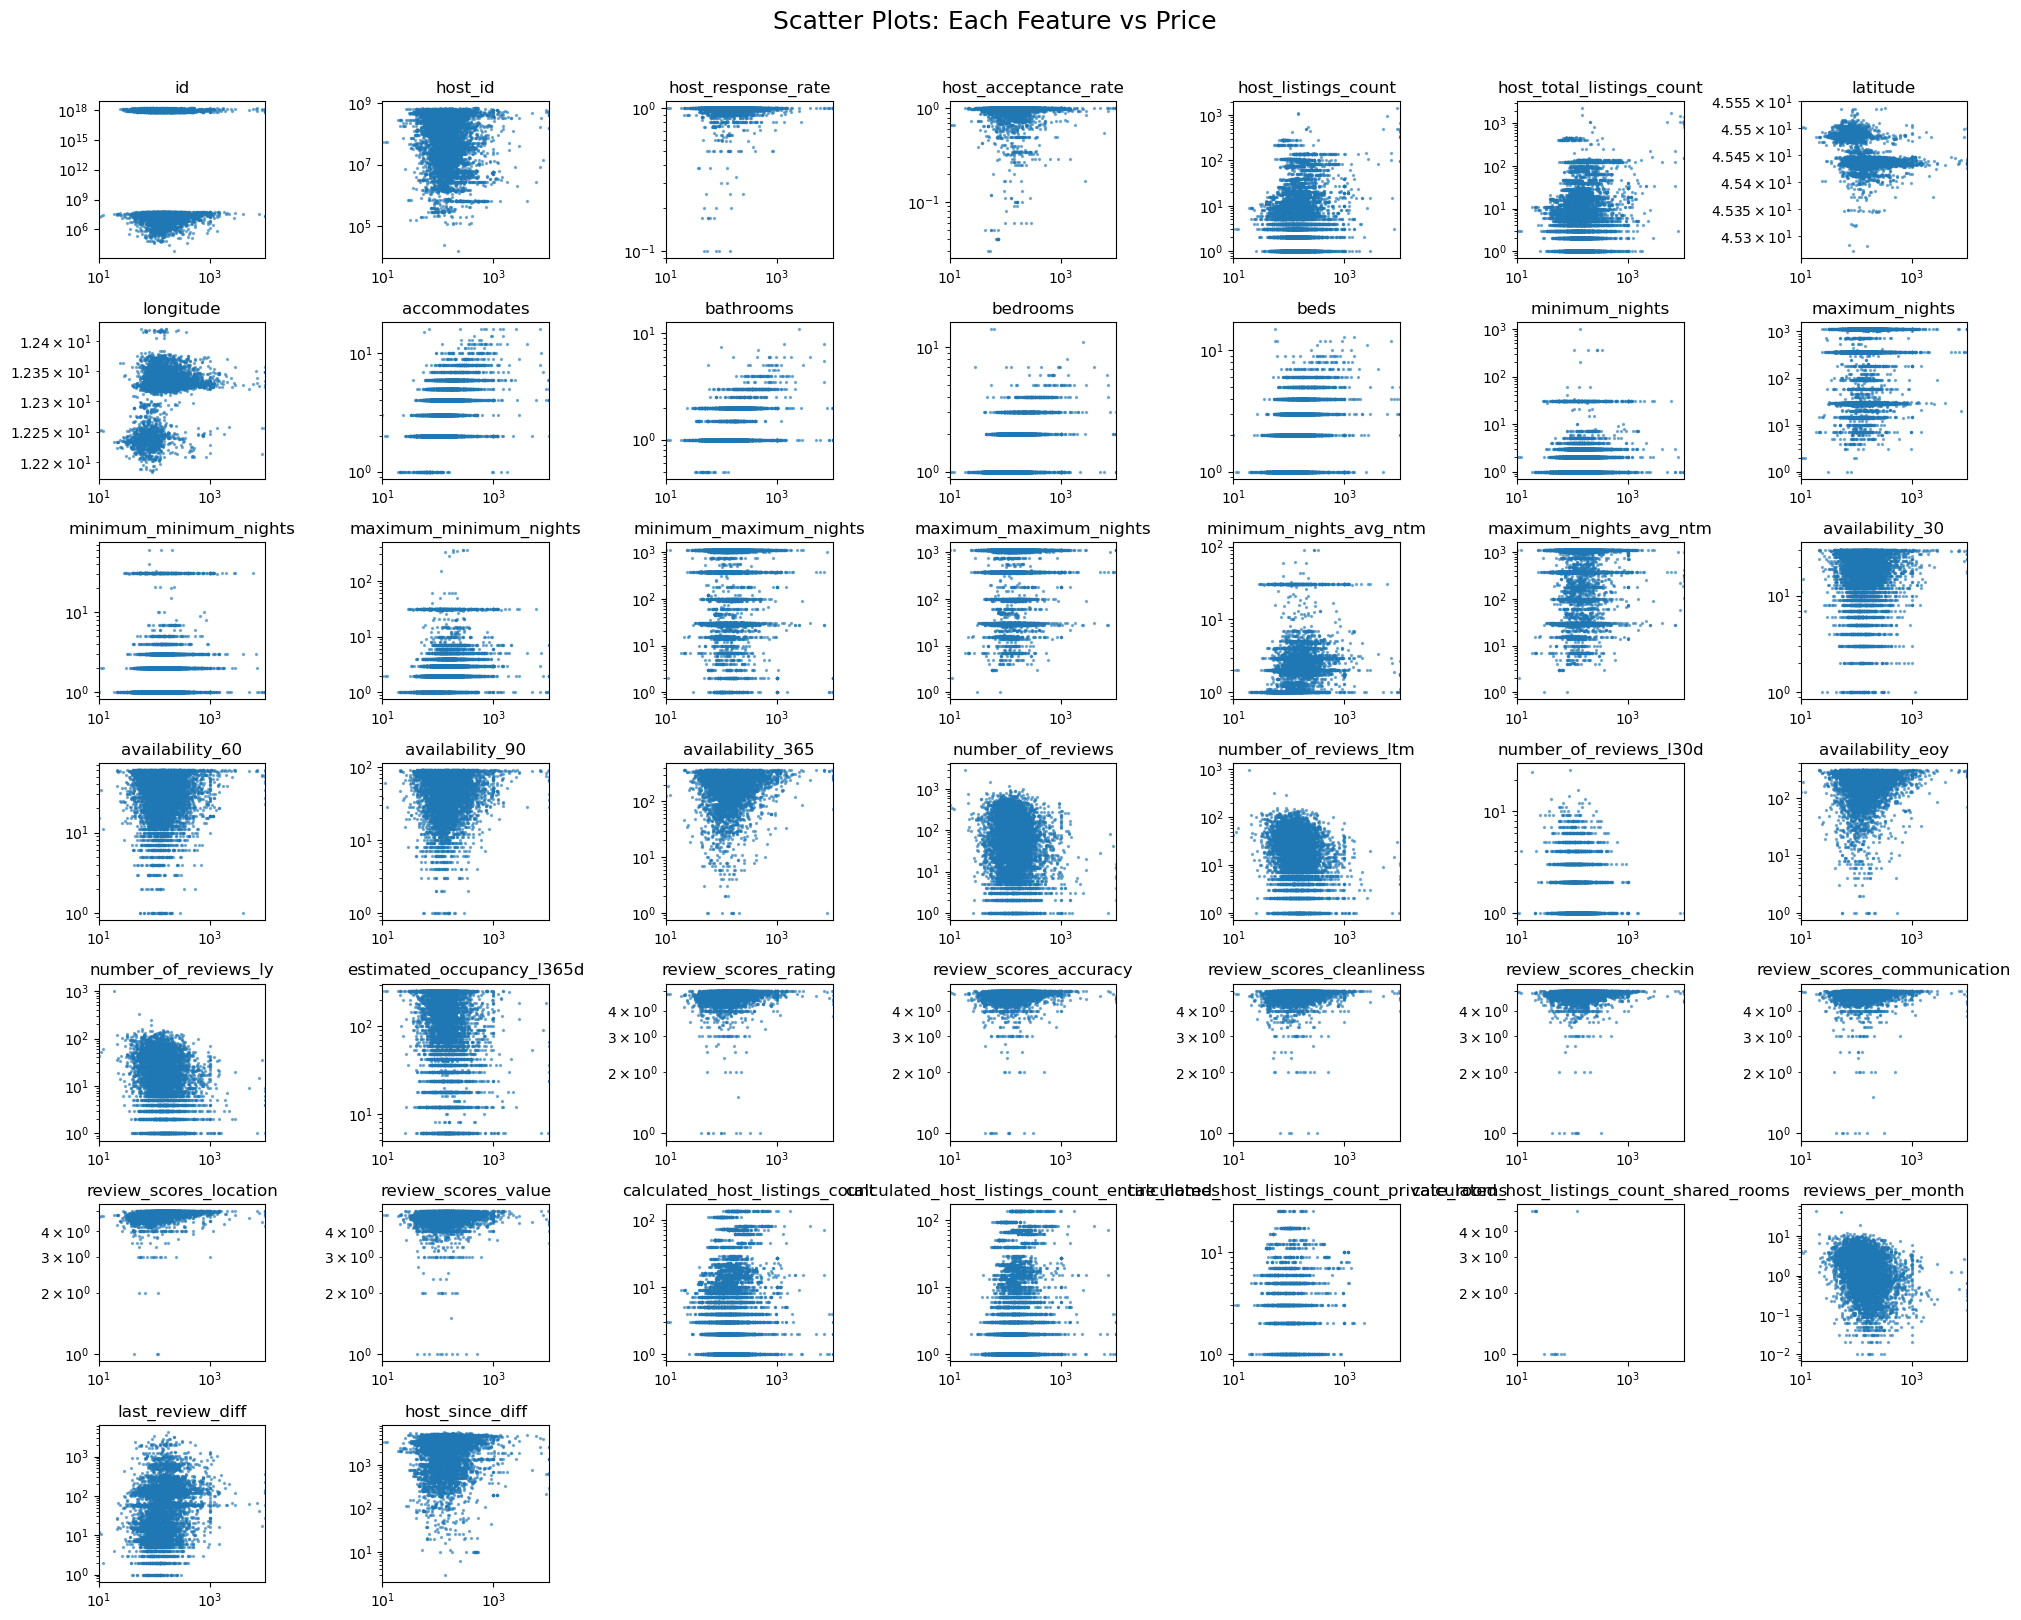

In [14]:
import matplotlib.pyplot as plt

# Scatter plots: target variable vs features
def scatter_plots(df, numerical_columns, target_clm):
    y = df[target_clm]
    max = y.max()
    min = y.min()

    plt.figure(figsize=(20, 17))
    plt.suptitle('Scatter Plots: Each Feature vs Price', fontsize=18)

    for i, feature in enumerate(numerical_columns):
        plt.subplot(7, 7, i + 1)
        plt.scatter(y.ravel(), df[feature], s=2, alpha=0.5)
        plt.title(feature, fontsize=12)
        plt.xlim(min, max)
        plt.xscale('log')
        plt.yscale('log')
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


target_clm = 'price'
numerical_columns = listings.select_dtypes(include=['number']).columns.tolist()
numerical_columns.remove(target_clm)
print(len(numerical_columns))



scatter_plots(listings, numerical_columns, target_clm)

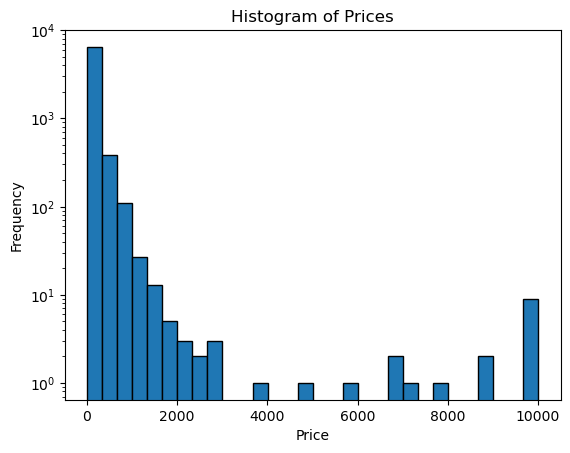

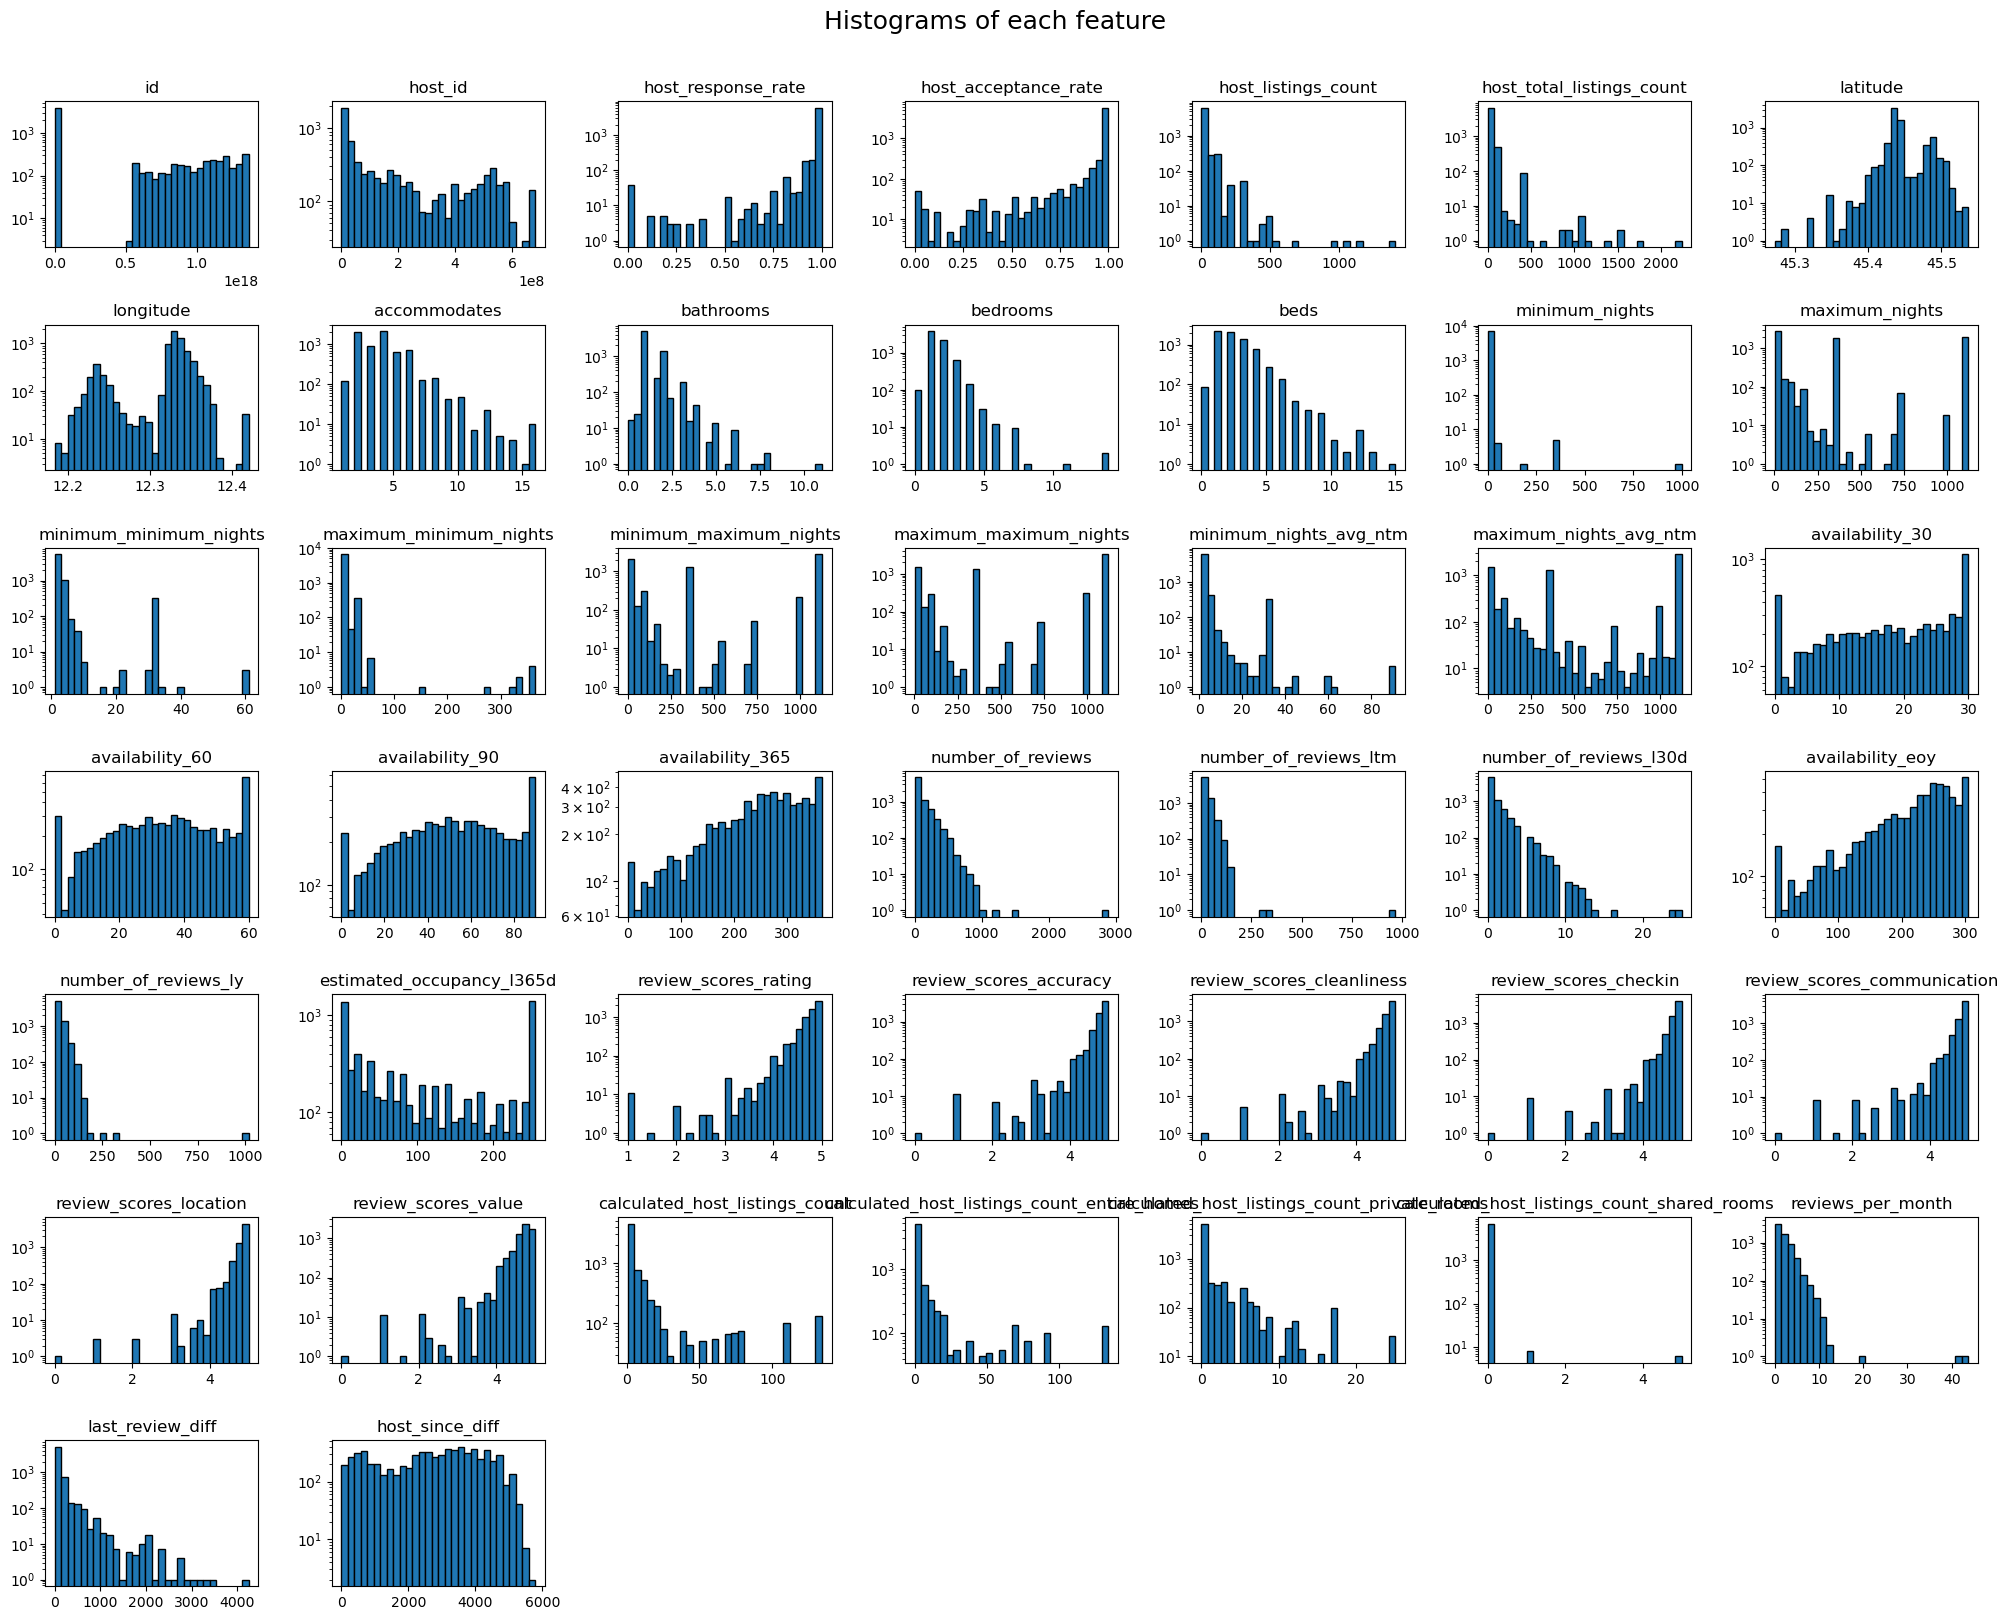

In [15]:
# Scatter plots: target variable vs features
def histograms(df, numerical_columns, target_clm):

    plt.hist(df[target_clm], bins=30, edgecolor='black')
    plt.title('Histogram of Prices')
    plt.yscale('log')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(20, 17))
    plt.suptitle('Histograms of each feature', fontsize=18)

    for i, feature in enumerate(numerical_columns):
        counts = (df[feature].value_counts())
        plt.subplot(7, 7, i + 1)
        plt.hist(df[feature], bins=30, edgecolor='black')
        # plt.bar(counts.index, counts.values)
        plt.title(feature, fontsize=12)
        # plt.xscale('log')
        plt.yscale('log')
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


histograms(listings, numerical_columns, target_clm)

C:\Users\bendi\AppData\Local\Temp\ipykernel_980\1758842130.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df[target_clm] = df[target_clm]


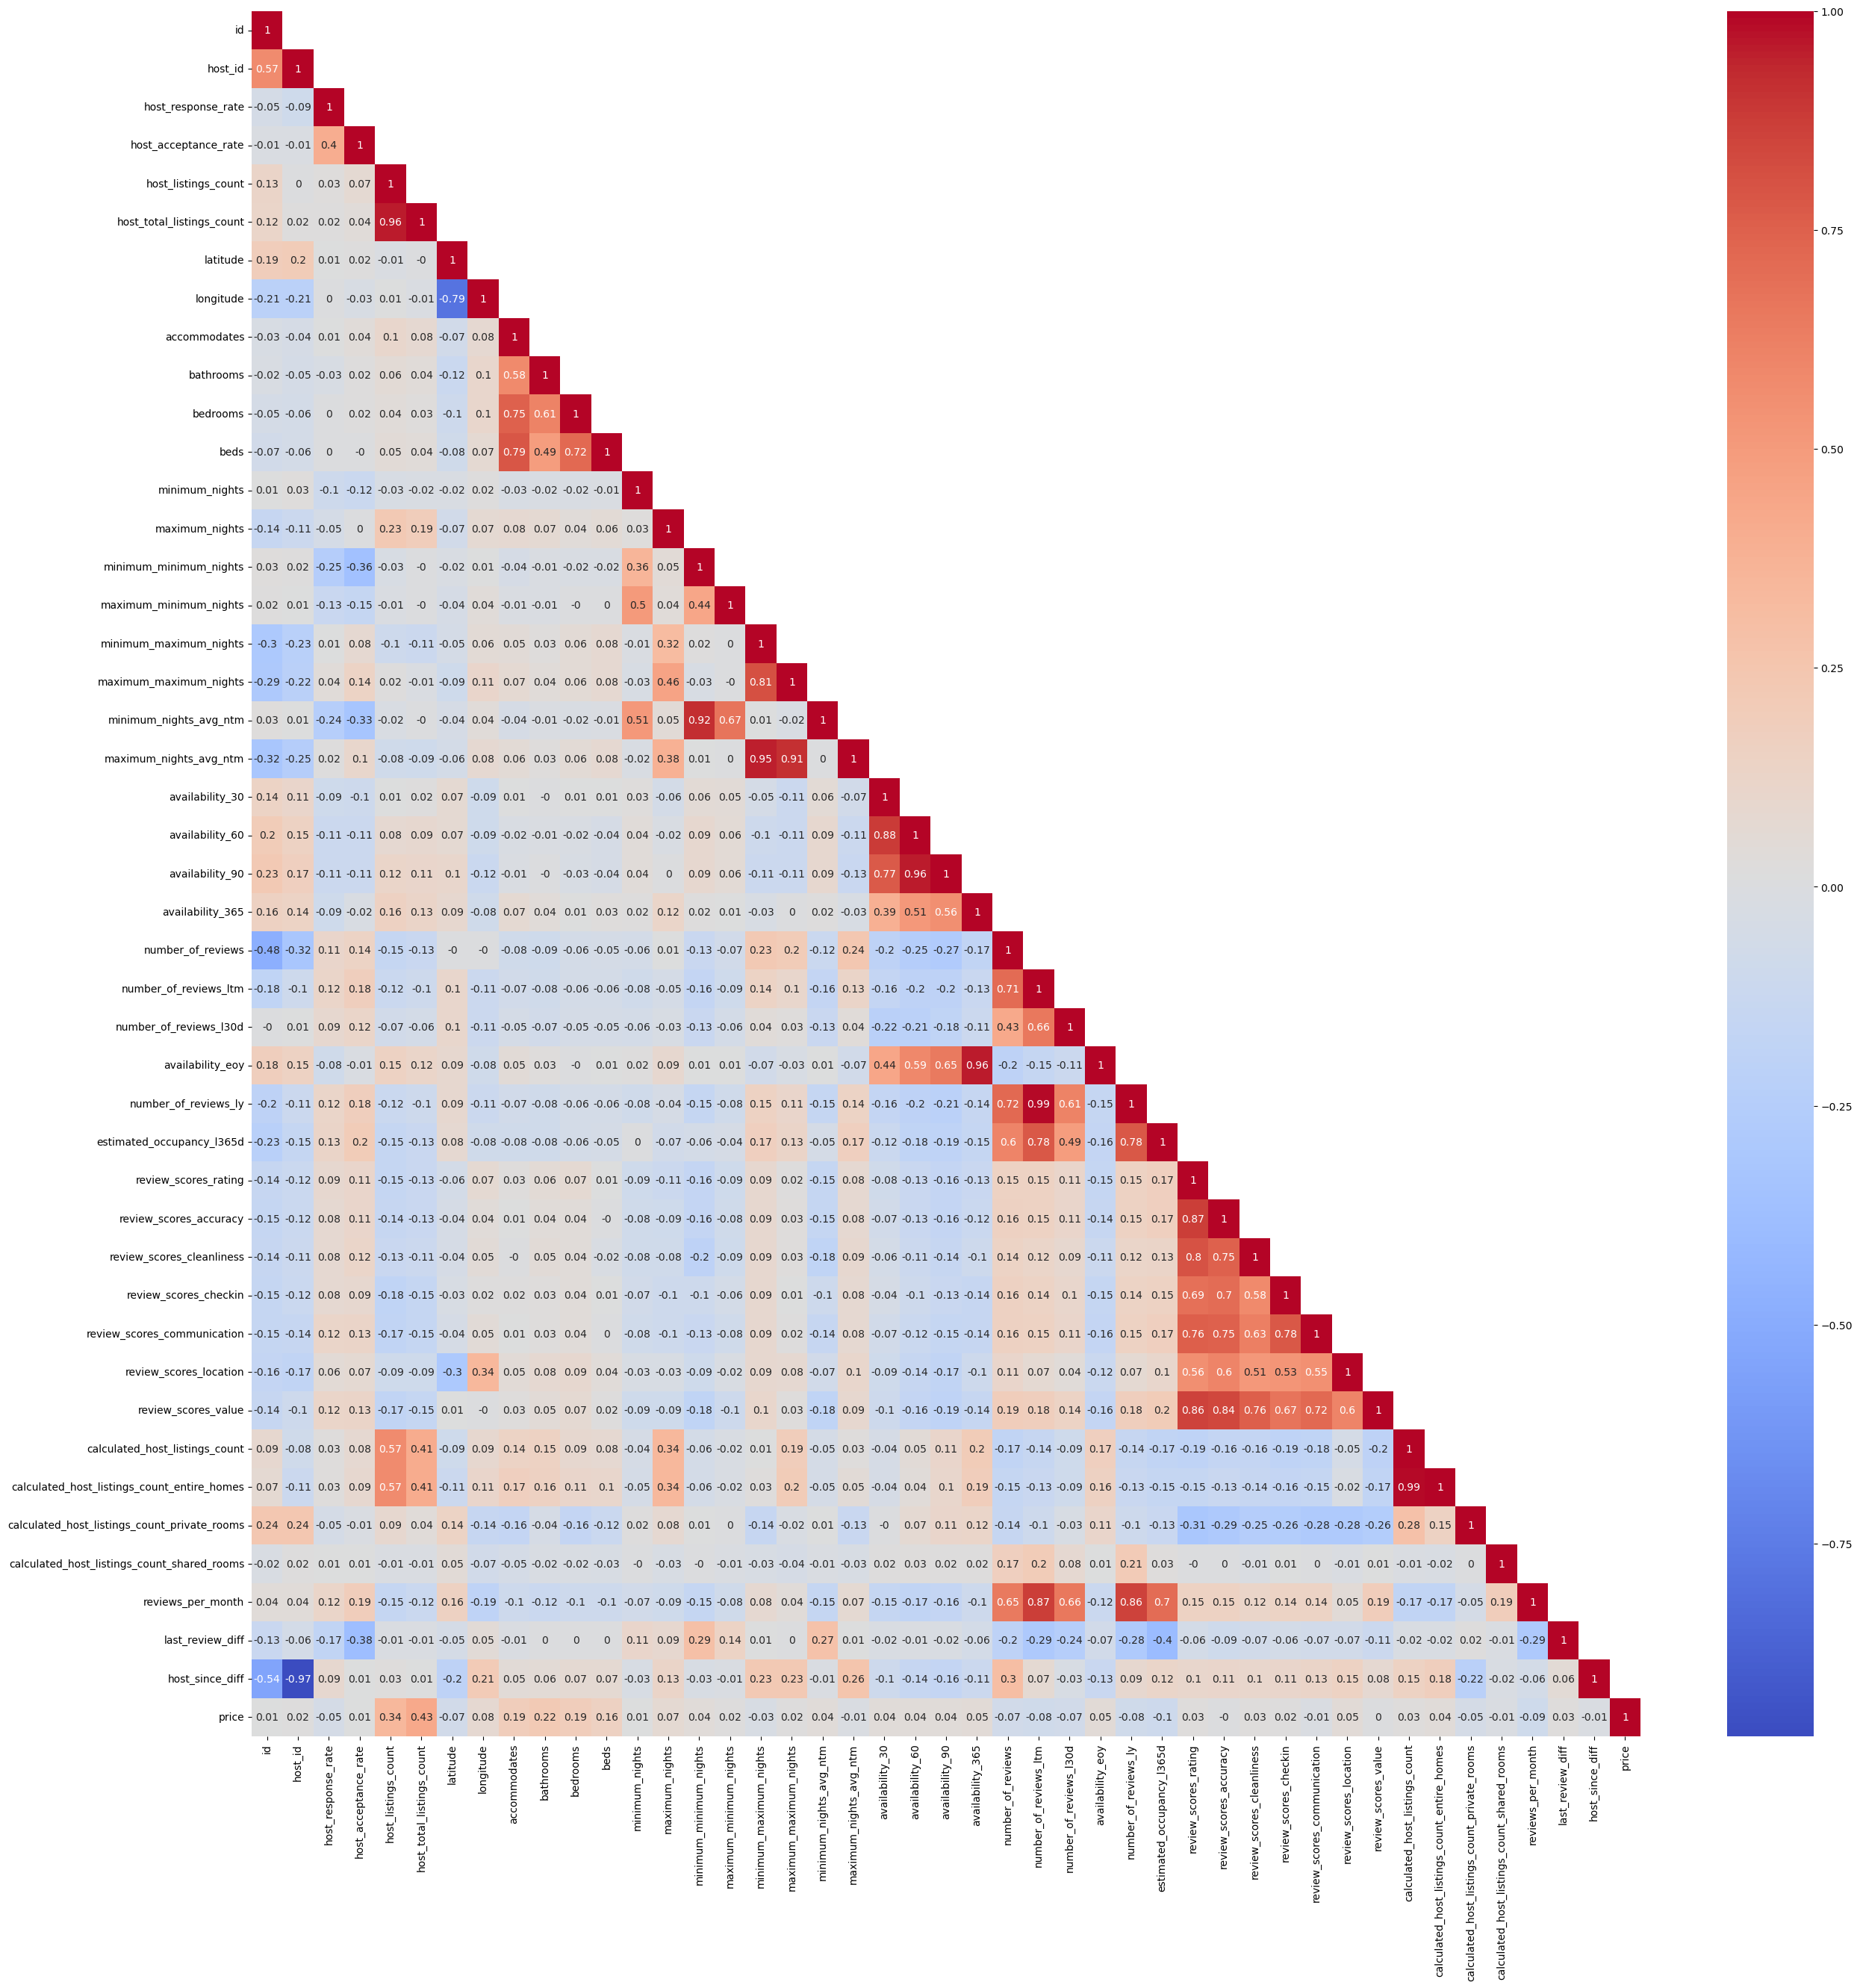

In [16]:
import seaborn as sns

def correlation_matrix(df, numerical_columns, target_clm):
    # correlation of features
    corr_df = df[numerical_columns]
    corr_df[target_clm] = df[target_clm]

    # compute the pair wise correlation for all columns  
    correlation_matrix = corr_df.corr().round(2)

    # print heatmap of the correlation matrix
    # next two lines remove the duplicate upper half of matrix
    mask = np.zeros(correlation_matrix.shape, dtype=bool)
    mask[np.triu_indices(len(mask),1)] = True

    plt.figure(figsize=(30, 30))
    sns.heatmap(data=correlation_matrix, annot=True, cmap = "coolwarm", mask = mask)


correlation_matrix(listings, numerical_columns, target_clm)

C:\Users\bendi\AppData\Local\Temp\ipykernel_980\1758842130.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df[target_clm] = df[target_clm]


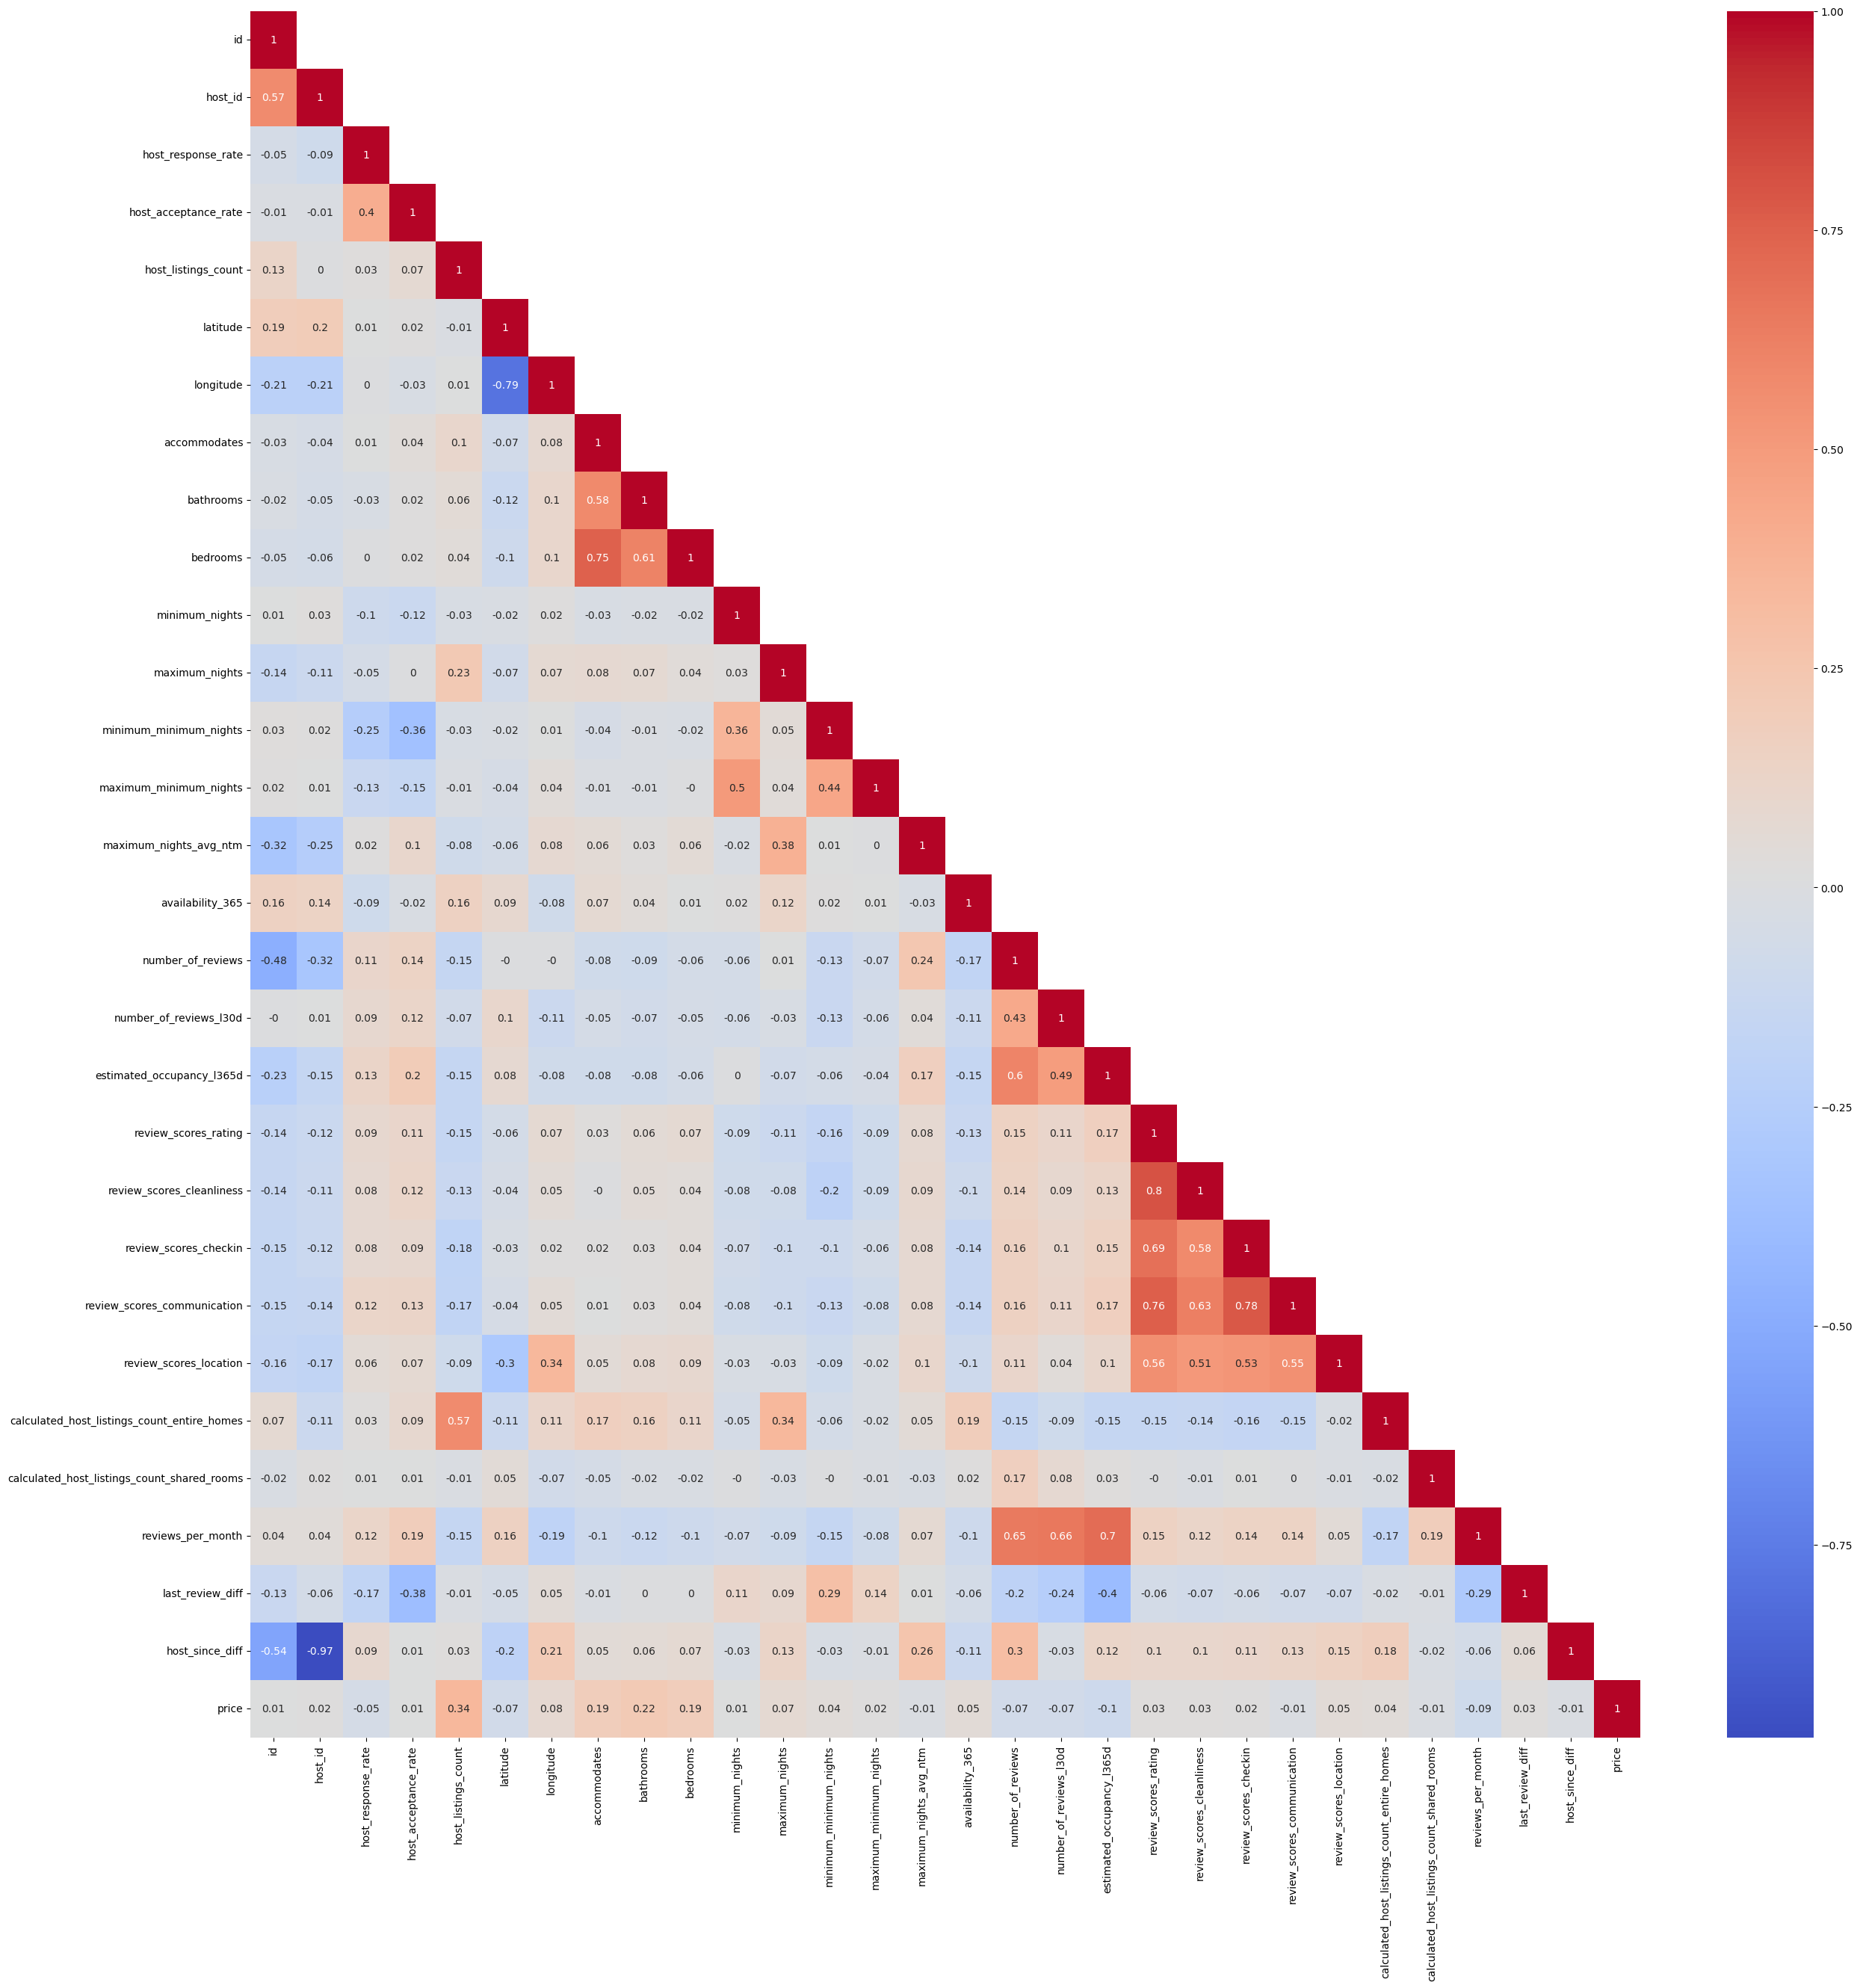

In [17]:
# delete features, which are high correlated to other features apart from price
delet_columns = ['host_total_listings_count', 'beds', 'minimum_nights_avg_ntm', 'maximum_maximum_nights', 'minimum_maximum_nights', 'availability_30', 'availability_90', 'availability_60', 'availability_eoy', 'number_of_reviews_ltm', 'number_of_reviews_ltm', 'review_scores_accuracy', 'review_scores_value', 
                 'calculated_host_listings_count', 'calculated_host_listings_count_private_rooms', 'number_of_reviews_ly', 'host_location', 'host_response_time']
listings = listings.drop(delet_columns, axis=1)

numerical_columns = listings.select_dtypes(include=['number']).columns.tolist()
numerical_columns.remove(target_clm)

correlation_matrix(listings, numerical_columns, target_clm)


## 6. Deleting Rows / Impute Values

Imputing values and deleting rows where values can not be imputed

In [18]:
missing_df = prep.missing_info(listings, 'id', sort_clmn='percent_missing', sort_ascending=False)
missing_df.head(10)

,column,dtype,num_missing,percent_missing,affected_row_ids
0,review_scores_location,float64,579,8.25,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
1,review_scores_checkin,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
2,last_review_diff,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
3,reviews_per_month,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
4,review_scores_communication,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
5,review_scores_rating,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
6,review_scores_cleanliness,float64,578,8.24,"[2014854, 3118010, 6782983, 6488939, 6552897, ..."
7,host_response_rate,float64,462,6.58,"[423767, 641360, 648497, 846521, 926604, 99944..."
8,host_is_superhost,object,274,3.90,"[831560, 335961, 357073, 1503769, 1753171, 287..."
9,host_acceptance_rate,float64,192,2.74,"[641360, 648497, 926604, 1034213, 1181536, 412..."


In [19]:
def mean_imputing(df, features):
    for feature in features:
        mean = df[feature].mean()
        df[feature].fillna(mean, inplace=True)


review_score_features = ['review_scores_location', 'reviews_per_month', 'review_scores_communication', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_rating', 'last_review_diff', 'host_response_rate', 'host_acceptance_rate']
mean_imputing(listings, review_score_features)


listings['description'] = listings['description'].fillna('')


listings['host_is_superhost'].fillna('nan', inplace=True)

C:\Users\bendi\AppData\Local\Temp\ipykernel_980\3625617632.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(mean, inplace=True)
C:\Users\bendi\AppData\Local\Temp\ipykernel_980\3625617632.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [20]:
missing_df = prep.missing_info(listings, 'id', sort_clmn='percent_missing', sort_ascending=False)
missing_df.head(12)

,column,dtype,num_missing,percent_missing,affected_row_ids
0,host_since_diff,float64,9,0.13,"[28071011, 33010115, 849904983657757980, 84993..."
1,host_listings_count,float64,9,0.13,"[28071011, 33010115, 849904983657757980, 84993..."
2,has_availability,object,9,0.13,"[45108052, 1279558795865919959, 12796078493227..."
3,host_identity_verified,object,9,0.13,"[28071011, 33010115, 849904983657757980, 84993..."
4,host_has_profile_pic,object,9,0.13,"[28071011, 33010115, 849904983657757980, 84993..."
5,bathrooms_text,object,4,0.06,"[1316352, 15812750, 32118463, 1016695412752790..."
6,bathrooms,float64,2,0.03,"[1316352, 1016695412752790117]"
7,bedrooms,float64,2,0.03,"[1581387, 1207581483275385888]"
8,picture_url,object,1,0.01,[1279558795865919959]
9,host_acceptance_rate,float64,0,0.00,[]


In [21]:
listings = listings.drop(['last_scraped'], axis=1)

listings = listings.dropna()
listings.to_csv('listings_cleaned.csv', index=False)

listings.shape

(6993, 44)

# Unused stuff that was developed

In [39]:
prep.calc_distribution(1.,'beds', 'bedrooms', listings)

,bedrooms,Probability
0,1.0,0.947175
1,0.0,0.027102
2,2.0,0.020211
3,3.0,0.004134
4,7.0,0.000919
5,4.0,0.000459


In [40]:
beds_distribution_dict = {value: prep.calc_distribution(value, 'beds', 'bedrooms', listings) 
                          for value in listings['beds'].dropna().unique()}
print(beds_distribution_dict)

listings['bedrooms'] = listings.apply(
     lambda row: prep.distribution_imputation(row, 'beds', 'bedrooms', beds_distribution_dict), axis=1)

{6.0:    bedrooms  Probability
0       3.0     0.362963
1       2.0     0.288889
2       4.0     0.214815
3       1.0     0.066667
4       5.0     0.037037
5       6.0     0.022222
6       7.0     0.007407, 2.0:    bedrooms  Probability
0       1.0     0.612294
1       2.0     0.369797
2       0.0     0.015005
3       3.0     0.002904, 3.0:    bedrooms  Probability
0       2.0     0.627790
1       1.0     0.225342
2       3.0     0.138949
3       0.0     0.005040
4       4.0     0.002880, 1.0:    bedrooms  Probability
0       1.0     0.947175
1       0.0     0.027102
2       2.0     0.020211
3       3.0     0.004134
4       7.0     0.000919
5       4.0     0.000459, 4.0:    bedrooms  Probability
0       2.0     0.537772
1       3.0     0.288092
2       1.0     0.115237
3       4.0     0.057618
4       0.0     0.001280, 5.0:    bedrooms  Probability
0       3.0     0.467153
1       2.0     0.317518
2       4.0     0.135036
3       1.0     0.047445
4       5.0     0.032847, 7.0:    bedro

### Bathrooms

- On the Airbnb web-site, the bathrooms field has evolved from a number (`bathrooms`) to a textual description (`bathrooms_text`). For older scrapes, `bathrooms` is used."

In [41]:
listings[['bathrooms', 'bathrooms_text']].head()

,bathrooms,bathrooms_text
0,2.0,2 baths
1,1.0,1 private bath
2,2.0,2 baths
3,1.0,1 private bath
4,1.0,1 bath


In [42]:
listings[['bathrooms_num', 'bathrooms_type']] = listings['bathrooms_text'].str.split(' ', n=1, expand=True)
listings['bathrooms_num'] = pd.to_numeric(listings['bathrooms_num'], errors='coerce')
listings[['bathrooms', 'bathrooms_text', 'bathrooms_num', 'bathrooms_type']].head()

,bathrooms,bathrooms_text,bathrooms_num,bathrooms_type
0,2.0,2 baths,2.0,baths
1,1.0,1 private bath,1.0,private bath
2,2.0,2 baths,2.0,baths
3,1.0,1 private bath,1.0,private bath
4,1.0,1 bath,1.0,bath


In [43]:
print(listings['bathrooms_type'].unique())

['baths' 'private bath' 'bath' 'shared bath' 'half-bath' nan
 'shared baths' None]


In [44]:
print(listings['bathrooms_text'].unique())

['2 baths' '1 private bath' '1 bath' '1 shared bath' '1.5 baths' '4 baths'
 'Shared half-bath' '3 baths' '2.5 baths' nan '5 baths' '0 baths'
 '2 shared baths' '4.5 baths' 'Half-bath' '1.5 shared baths'
 '3 shared baths' '6 baths' '3.5 baths' '0 shared baths' '5.5 baths'
 '11 baths' '2.5 shared baths' '7.5 baths' 'Private half-bath' '8 baths'
 '7 baths']


In [45]:
# show rows where bathroom and bathrooms_num differ
filtered_listings = listings[(listings['bathrooms_num'] != listings['bathrooms'])]
filtered_listings[['bathrooms', 'bathrooms_text', 'bathrooms_num', 'bathrooms_type']].head()

,bathrooms,bathrooms_text,bathrooms_num,bathrooms_type
45,0.5,Shared half-bath,NaN,half-bath
62,0.5,Shared half-bath,NaN,half-bath
166,0.5,Shared half-bath,NaN,half-bath
236,NaN,NaN,NaN,NaN
618,0.5,Half-bath,NaN,None


In [46]:
filtered_listings = listings[listings['bathrooms'].isnull()]
filtered_listings[['bathrooms', 'bathrooms_text', 'bathrooms_type']]

,bathrooms,bathrooms_text,bathrooms_type
236,NaN,NaN,NaN
5973,NaN,NaN,NaN


In [47]:
listings = listings.drop(['bathrooms_text', 'bathrooms'], axis=1)